In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [2]:
df = pd.read_csv('Admission_Predict.csv')


In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (400, 9)


In [4]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3           4        322          110                  3  3.5   2.5  8.67   
4           5        314          103                  2  2.0   3.0  8.21   

   Research  Chance of Admit   
0         1              0.92  
1         1              0.76  
2         1              0.72  
3         1              0.80  
4         0              0.65  


In [5]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB
None


In [6]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       Serial No.   GRE Score  TOEFL Score  University Rating         SOP  \
count  400.000000  400.000000   400.000000         400.000000  400.000000   
mean   200.500000  316.807500   107.410000           3.087500    3.400000   
std    115.614301   11.473646     6.069514           1.143728    1.006869   
min      1.000000  290.000000    92.000000           1.000000    1.000000   
25%    100.750000  308.000000   103.000000           2.000000    2.500000   
50%    200.500000  317.000000   107.000000           3.000000    3.500000   
75%    300.250000  325.000000   112.000000           4.000000    4.000000   
max    400.000000  340.000000   120.000000           5.000000    5.000000   

             LOR         CGPA    Research  Chance of Admit   
count  400.000000  400.000000  400.000000        400.000000  
mean     3.452500    8.598925    0.547500          0.724350  
std      0.898478    0.596317    0.498362          0.142609  
min      1.000000    6.800000    0.0

In [7]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64


In [8]:
# Drop Serial No. as it's not useful for prediction
df = df.drop('Serial No.', axis=1)

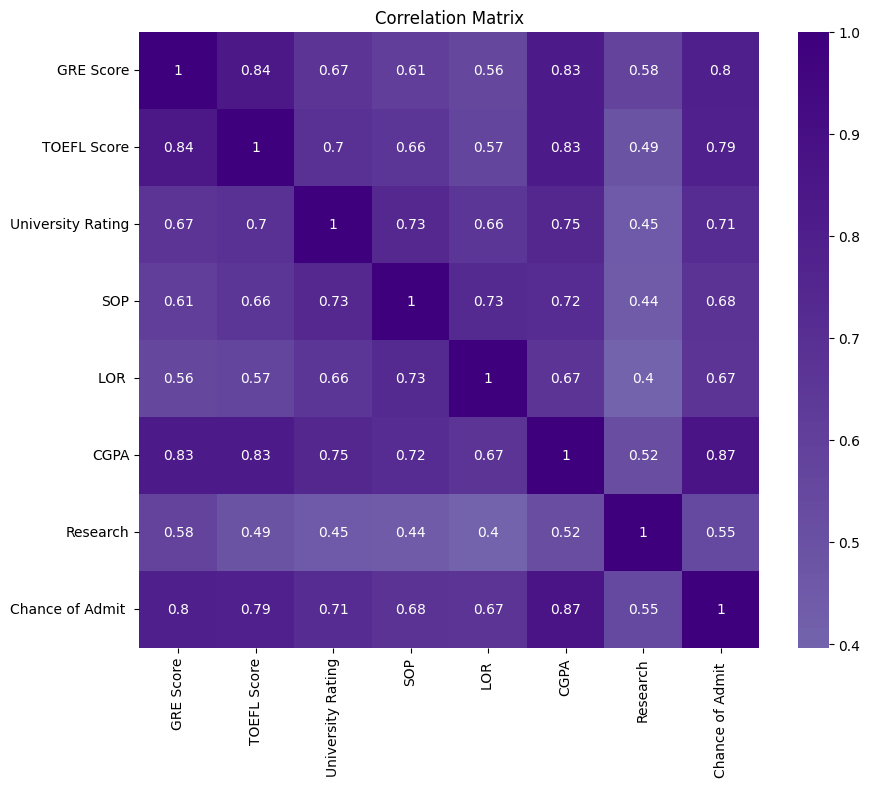


Correlation with Chance of Admit:
Chance of Admit      1.000000
CGPA                 0.873289
GRE Score            0.802610
TOEFL Score          0.791594
University Rating    0.711250
SOP                  0.675732
LOR                  0.669889
Research             0.553202
Name: Chance of Admit , dtype: float64


In [9]:
# Check the correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='Purples', center=0)
plt.title('Correlation Matrix')
plt.show()

# Display correlation with target variable
print("\nCorrelation with Chance of Admit:")
print(correlation_matrix['Chance of Admit '].sort_values(ascending=False))

In [10]:
# Prepare features and target
X = df.drop('Chance of Admit ', axis=1)
y = df['Chance of Admit ']

In [11]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
  # Make predictions
y_pred = model.predict(X_test)
    
# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
    
print("=== Model Training Results ===")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

=== Model Training Results ===
R² Score: 0.8212
RMSE: 0.0679
MAE: 0.0480


In [14]:
# Display coefficients
print("\n=== Feature Coefficients ===")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature:20}: {coef:>8.4f}")
print(f"{'Intercept':20}: {model.intercept_:>8.4f}")


=== Feature Coefficients ===
GRE Score           :   0.0019
TOEFL Score         :   0.0027
University Rating   :   0.0074
SOP                 :  -0.0003
LOR                 :   0.0158
CGPA                :   0.1147
Research            :   0.0222
Intercept           :  -1.2302


In [15]:
# Save model
with open('finalized_model.pickle', 'wb') as file:
    pickle.dump(model, file)
    print("\nModel saved as 'finalized_model.pickle'")


Model saved as 'finalized_model.pickle'


In [16]:
def test_saved_model():
    # Load the saved model
    with open('finalized_model.pickle', 'rb') as file:
        loaded_model = pickle.load(file)
    
    # Create sample input (using the same feature order)
    sample_input = [[337, 118, 4, 4, 4, 9, 1]]  # From first row
    
    # Make prediction
    prediction = loaded_model.predict(sample_input)
    print(f"Sample prediction: {prediction[0]:.3f} (Actual: 0.92)")
    
    return loaded_model

# Test the model
test_saved_model()

Sample prediction: 0.864 (Actual: 0.92)


c:\Users\prabh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
